# Metropolis-Hastings and Adaptive MCMC

**Author:** Bahareh Keshavarz  
**Academic origin:** VUB Adaptive Systems coursework, developed into a public reproducible project

## Purpose

This notebook explains Markov Chain Monte Carlo with emphasis on Metropolis-Hastings, proposal design, diagnostics, and Adaptive Metropolis. It contains the mathematical motivation, deterministic experiments, plots, and conclusions in one place.


## 1. Fundamental ideas

### 1.1 Monte Carlo sampling

In probability and statistics, we often want to compute an expectation of the form

$$
\mathbb{E}_{\pi}[h(X)] = \int h(x)\pi(x)\,dx,
$$

where $\pi(x)$ is a probability density and $h(x)$ is a function of interest.

If we can generate independent samples $x_1, x_2, \dots, x_N$ from $\pi$, then we approximate the expectation by

$$
\frac{1}{N}\sum_{n=1}^{N} h(x_n).
$$

This is the basic Monte Carlo idea. The problem is that for many interesting distributions, direct independent sampling is difficult.

### 1.2 Markov chains

A **Markov chain** is a stochastic process $X_0, X_1, X_2, \dots$ with the property that the next state depends only on the current state:

$$
P(X_{n+1} \in A \mid X_n, X_{n-1}, \dots, X_0) = P(X_{n+1} \in A \mid X_n).
$$

So the present contains all the information needed to move to the future.

### 1.3 Invariant distribution

A probability distribution $\pi$ is called **invariant** for a Markov chain if, once the chain has distribution $\pi$, it keeps that distribution forever.

This matters because MCMC methods are designed to construct a Markov chain whose invariant distribution is exactly the target distribution we want to sample from.

### 1.4 Why MCMC?

MCMC methods do not generate independent samples. Instead, they generate a dependent sequence of samples from a Markov chain. If the chain is well designed and run long enough, the states visited by the chain behave like samples from the target distribution.

So the key idea is:

- choose a target density $\pi(x)$,
- design a Markov chain with invariant distribution $\pi$,
- run the chain,
- use the resulting samples to estimate expectations and other properties of $\pi$.


## 2. Metropolis-Hastings

### 2.1 Core idea

Suppose the current state is $x$. We first propose a candidate state $y$ from a proposal distribution $q(y \mid x)$. Then we decide whether to accept or reject that candidate.

The Metropolis-Hastings acceptance probability is

$$
\alpha(x, y) = \min\left(1, \frac{\pi(y)q(x \mid y)}{\pi(x)q(y \mid x)}\right).
$$

Then:

- with probability $\alpha(x,y)$ we move to $y$,
- otherwise we stay at $x$.

### 2.2 Why this works

The algorithm is constructed so that the chain satisfies **detailed balance**:

$$
\pi(x)P(x,y) = \pi(y)P(y,x).
$$

Detailed balance implies reversibility, and reversibility implies that $\pi$ is an invariant distribution of the Markov chain.

This is the main mathematical reason why Metropolis-Hastings is valid.

### 2.3 Symmetric and asymmetric proposals

If the proposal is symmetric, then

$$
q(y \mid x) = q(x \mid y),
$$

and the acceptance rule simplifies to

$$
\alpha(x, y) = \min\left(1, \frac{\pi(y)}{\pi(x)}\right).
$$

If the proposal is asymmetric, we must keep the extra proposal ratio

$$
\frac{q(x \mid y)}{q(y \mid x)}.
$$

This correction is the difference between the original Metropolis method and the more general Metropolis-Hastings algorithm.


## 3. What makes an MCMC chain good or bad?

A chain can be correct in theory and still be inefficient in practice.

Important practical concepts are:

- **Burn-in:** early samples may still reflect the starting point, so they are often discarded.
- **Mixing:** how quickly the chain moves through the important regions of the target distribution.
- **Autocorrelation:** successive samples are dependent; high autocorrelation means less information per sample.
- **Effective Sample Size (ESS):** approximate number of independent samples represented by the correlated chain.

If two chains have the same length, the one with lower autocorrelation and higher ESS is more useful.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, multivariate_normal

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)


In [2]:
from mcmc_research import (
    MCMCResult, adaptive_metropolis, autocorrelation,
    correlated_gaussian_logpdf, effective_sample_size,
    integrated_autocorrelation_time, lognormal_logpdf,
    lognormal_pdf, multiplicative_metropolis_1d,
    random_walk_metropolis_1d, random_walk_metropolis_nd,
    running_mean, summarize_1d, summarize_nd,
)


## 4. Experiment 1: Metropolis-Hastings on an asymmetric heavy-tailed target

The first experiment follows the topic of the Metropolis-Hastings chapter.

I use the **log-normal distribution** with parameters $\mu = 2.0$ and $\sigma = 0.75$ as target:

$$
X \sim \operatorname{LogNormal}(2.0, 0.75).
$$

This target is a good example because:

- it is supported only on positive values,
- it is asymmetric,
- it has a long right tail.

These properties make the choice of proposal distribution important.

### Proposals compared

I compare two proposals:

1. **Additive random-walk proposal**

   $$
   y = x + \varepsilon, \quad \varepsilon \sim U(-\rho, \rho).
   $$

   This proposal is symmetric, so its acceptance rule is the simple Metropolis ratio.

2. **Multiplicative proposal**

   $$
   y = x\exp(u), \quad u \sim U(-\rho, \rho).
   $$

   This proposal is more natural for a positive skewed target because it moves in the log-domain.
   It is asymmetric in the original domain, so the Hastings correction must be included.


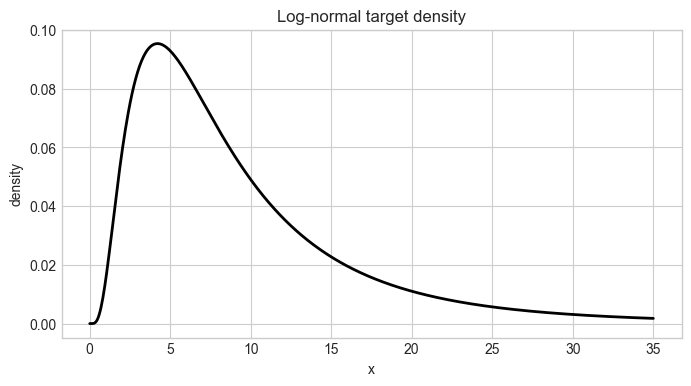

Exact mean   = 9.789
Exact median = 7.389


In [3]:
MU = 2.0
SIGMA = 0.75
N_STEPS_1D = 20_000
BURN_IN_1D = 2_000
SCALES_1D = [0.4, 1.0, 2.0]

exact_mean = np.exp(MU + SIGMA ** 2 / 2)
exact_median = np.exp(MU)

x_grid = np.linspace(0.001, 35, 600)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_grid, lognormal_pdf(x_grid, mu=MU, sigma=SIGMA), color="black", lw=2)
ax.set_title("Log-normal target density")
ax.set_xlabel("x")
ax.set_ylabel("density")
plt.show()

print(f"Exact mean   = {exact_mean:.3f}")
print(f"Exact median = {exact_median:.3f}")


In [4]:
rows = []
chains_1d = {}

for scale in SCALES_1D:
    additive = random_walk_metropolis_1d(
        target_logpdf=lambda x: float(lognormal_logpdf(x, mu=MU, sigma=SIGMA)),
        initial_state=1.0,
        n_steps=N_STEPS_1D,
        step_scale=scale,
        rng=np.random.default_rng(1000 + int(scale * 100)),
    )

    multiplicative = multiplicative_metropolis_1d(
        target_logpdf=lambda x: float(lognormal_logpdf(x, mu=MU, sigma=SIGMA)),
        initial_state=1.0,
        n_steps=N_STEPS_1D,
        log_step_scale=scale,
        rng=np.random.default_rng(2000 + int(scale * 100)),
    )

    chains_1d[("Additive MH", scale)] = additive
    chains_1d[("Multiplicative MH", scale)] = multiplicative

    for sampler_name, result in [
        ("Additive MH", additive),
        ("Multiplicative MH", multiplicative),
    ]:
        summary = summarize_1d(result.samples, burn_in=BURN_IN_1D)
        rows.append(
            {
                "sampler": sampler_name,
                "scale": scale,
                "acceptance": result.acceptance_rate,
                "mean": summary["mean"],
                "median": summary["median"],
                "std": summary["std"],
                "IACT": summary["iact"],
                "ESS": summary["ess"],
            }
        )

heavy_tail_results = pd.DataFrame(rows).sort_values(["scale", "sampler"]).reset_index(drop=True)
heavy_tail_results


,sampler,scale,acceptance,mean,median,std,IACT,ESS
0,Additive MH,0.4,0.979,7.134,6.385,3.813,338.366,53.197
1,Multiplicative MH,0.4,0.891,9.334,7.101,7.877,45.818,392.857
2,Additive MH,1.0,0.949,8.212,6.848,5.528,275.454,65.347
3,Multiplicative MH,1.0,0.746,9.965,7.558,8.932,9.244,1947.202
4,Additive MH,2.0,0.908,8.454,6.941,5.600,123.011,146.328
5,Multiplicative MH,2.0,0.534,9.788,7.353,8.409,4.415,4077.308


### Reading the table

The table reports three important trade-offs:

- If the proposal scale is very small, acceptance becomes high, but the chain moves only a little at each step.
- If the proposal scale is too large, the chain proposes moves that are often rejected.
- A proposal better aligned with the geometry of the target should reduce autocorrelation and increase ESS.

For a heavy-tailed positive target, a multiplicative move is often more suitable than a purely additive move.


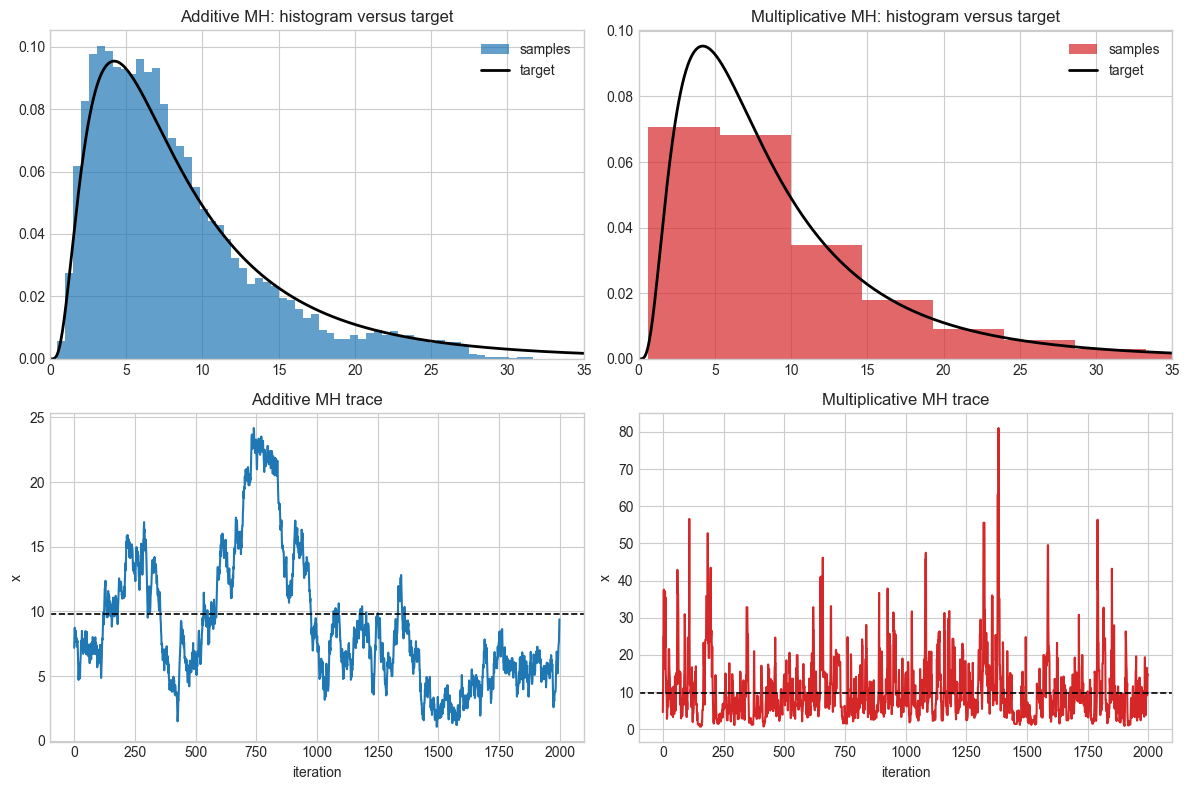

In [5]:
selected_scale = 1.0
additive_chain = chains_1d[("Additive MH", selected_scale)].samples[BURN_IN_1D:]
multiplicative_chain = chains_1d[("Multiplicative MH", selected_scale)].samples[BURN_IN_1D:]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(additive_chain, bins=60, density=True, alpha=0.70, color="#1f77b4", label="samples")
axes[0, 0].plot(x_grid, lognormal_pdf(x_grid, mu=MU, sigma=SIGMA), color="black", lw=2, label="target")
axes[0, 0].set_title("Additive MH: histogram versus target")
axes[0, 0].set_xlim(0, 35)
axes[0, 0].legend()

axes[0, 1].hist(multiplicative_chain, bins=60, density=True, alpha=0.70, color="#d62728", label="samples")
axes[0, 1].plot(x_grid, lognormal_pdf(x_grid, mu=MU, sigma=SIGMA), color="black", lw=2, label="target")
axes[0, 1].set_title("Multiplicative MH: histogram versus target")
axes[0, 1].set_xlim(0, 35)
axes[0, 1].legend()

axes[1, 0].plot(additive_chain[:2000], color="#1f77b4")
axes[1, 0].axhline(exact_mean, color="black", ls="--", lw=1.2)
axes[1, 0].set_title("Additive MH trace")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].set_ylabel("x")

axes[1, 1].plot(multiplicative_chain[:2000], color="#d62728")
axes[1, 1].axhline(exact_mean, color="black", ls="--", lw=1.2)
axes[1, 1].set_title("Multiplicative MH trace")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].set_ylabel("x")

plt.tight_layout()
plt.show()


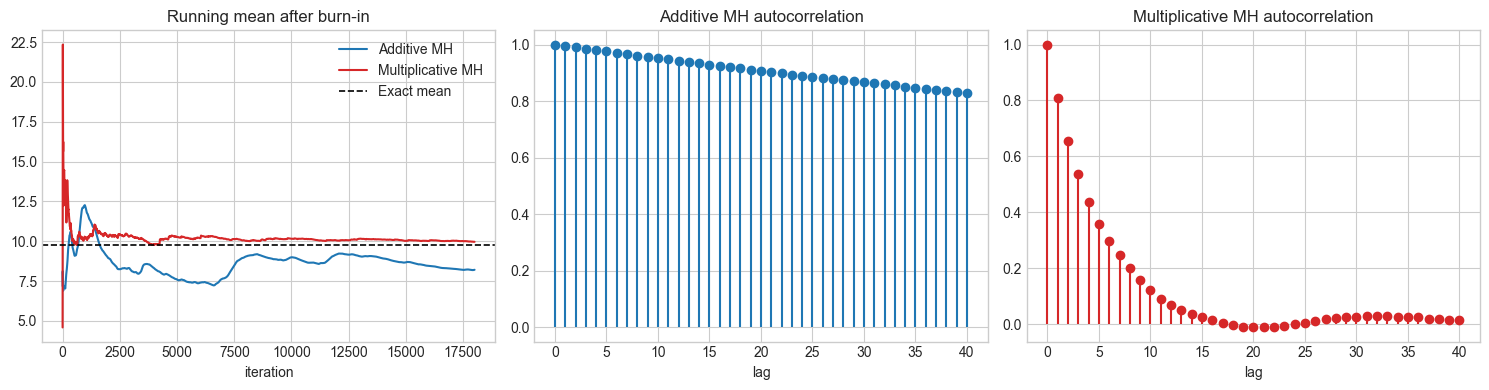

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(running_mean(additive_chain), color="#1f77b4", label="Additive MH")
axes[0].plot(running_mean(multiplicative_chain), color="#d62728", label="Multiplicative MH")
axes[0].axhline(exact_mean, color="black", ls="--", lw=1.2, label="Exact mean")
axes[0].set_title("Running mean after burn-in")
axes[0].set_xlabel("iteration")
axes[0].legend()

acf_add = autocorrelation(additive_chain, max_lag=40)
acf_mul = autocorrelation(multiplicative_chain, max_lag=40)

axes[1].stem(range(len(acf_add)), acf_add, basefmt=" ", linefmt="#1f77b4", markerfmt="o")
axes[1].set_title("Additive MH autocorrelation")
axes[1].set_xlabel("lag")

axes[2].stem(range(len(acf_mul)), acf_mul, basefmt=" ", linefmt="#d62728", markerfmt="o")
axes[2].set_title("Multiplicative MH autocorrelation")
axes[2].set_xlabel("lag")

plt.tight_layout()
plt.show()


### Conclusion of Experiment 1

The experiment shows that correctness alone is not the whole story. Both chains target the same distribution, but they do not have the same efficiency.

For this log-normal target, the multiplicative proposal tends to produce substantially lower autocorrelation and larger effective sample size. This makes sense mathematically because the target is positive and skewed, so multiplicative moves are better adapted to the shape of the state space.


## 5. Experiment 2: from basic MH to Adaptive Metropolis

Chapter 3 discusses broader MCMC methods. I focus on **Adaptive Metropolis (AM)** because it is a natural continuation of Metropolis-Hastings.

### Why adaptation is useful

In Metropolis-Hastings, the proposal distribution must be chosen by the user. This is delicate:

- if the proposal variance is too small, the chain mixes slowly;
- if the proposal variance is too large, many proposals are rejected;
- if the target is strongly correlated, a spherical proposal may point in inefficient directions.

Adaptive Metropolis attempts to learn the covariance structure from the history of the chain and update the proposal during sampling.

### Target distribution

I use a two-dimensional Gaussian target with covariance

$$
\Sigma =
\begin{pmatrix}
1 & 0.92 \\\\
0.92 & 1
\end{pmatrix}.
$$

The target has strong positive correlation, so it is a good example of a distribution whose geometry matters.


In [7]:
N_STEPS_2D = 15_000
BURN_IN_2D = 2_000
target_cov = np.array([[1.0, 0.92], [0.92, 1.0]])
initial_state_2d = np.array([5.0, -5.0])
target_2d = lambda x: correlated_gaussian_logpdf(x, covariance=target_cov)

rw_small = random_walk_metropolis_nd(
    target_logpdf=target_2d,
    initial_state=initial_state_2d,
    n_steps=N_STEPS_2D,
    proposal_covariance=np.array([[0.05, 0.0], [0.0, 0.05]]),
    rng=np.random.default_rng(3100),
)

rw_large = random_walk_metropolis_nd(
    target_logpdf=target_2d,
    initial_state=initial_state_2d,
    n_steps=N_STEPS_2D,
    proposal_covariance=np.array([[2.0, 0.0], [0.0, 2.0]]),
    rng=np.random.default_rng(3200),
)

am = adaptive_metropolis(
    target_logpdf=target_2d,
    initial_state=initial_state_2d,
    n_steps=N_STEPS_2D,
    rng=np.random.default_rng(3300),
    adapt_start=250,
    initial_scale=0.2,
)

sampler_results_2d = {
    "RW small": rw_small,
    "RW large": rw_large,
    "Adaptive Metropolis": am,
}

rows = []
for name, result in sampler_results_2d.items():
    summary = summarize_nd(result.samples, burn_in=BURN_IN_2D)
    cov = summary["cov"]
    corr = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rows.append(
        {
            "sampler": name,
            "acceptance": result.acceptance_rate,
            "mean_x": summary["mean"][0],
            "mean_y": summary["mean"][1],
            "corr_xy": corr,
            "ESS_x": summary["ess"][0],
            "ESS_y": summary["ess"][1],
        }
    )

adaptive_results = pd.DataFrame(rows).sort_values("sampler").reset_index(drop=True)
adaptive_results


,sampler,acceptance,mean_x,mean_y,corr_xy,ESS_x,ESS_y
0,Adaptive Metropolis,0.243,-0.009,-0.024,0.917,1122.770,1144.107
1,RW large,0.201,0.045,0.031,0.922,453.874,451.748
2,RW small,0.748,0.050,0.057,0.929,80.773,82.431


### What should we expect?

The target is elongated along a diagonal direction because the coordinates are highly correlated.

Therefore:

- a very small isotropic proposal should have high acceptance but poor exploration;
- a very large isotropic proposal should move farther, but often in unsuitable directions and with many rejections;
- an adaptive proposal should gradually estimate a covariance that better matches the target.


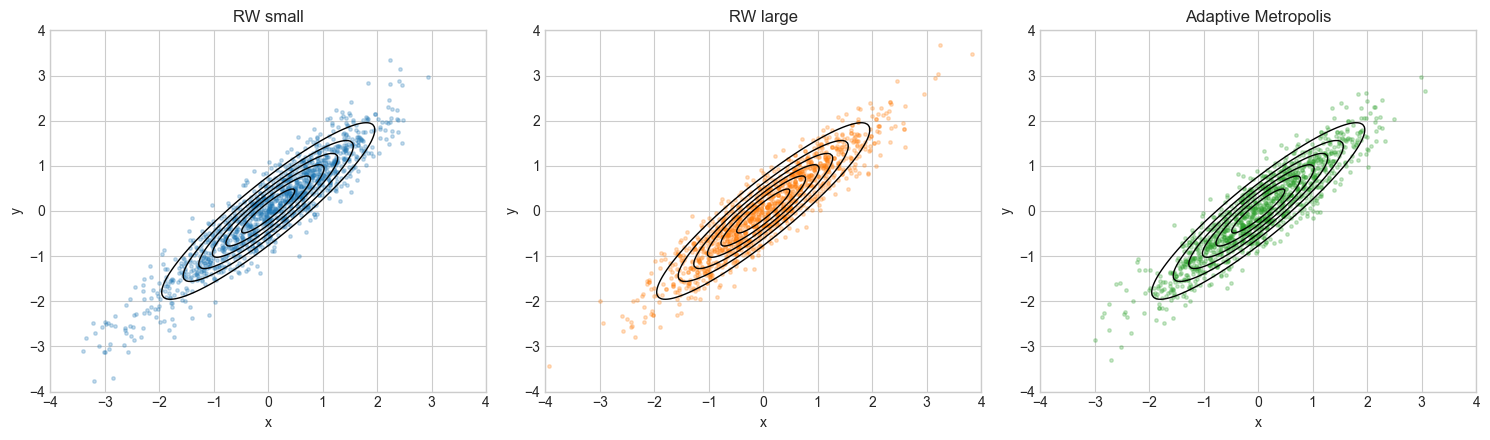

In [8]:
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
xx, yy = np.meshgrid(x, y)
pos = np.dstack((xx, yy))
density = multivariate_normal(mean=np.zeros(2), cov=target_cov).pdf(pos)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, result), color in zip(
    axes,
    sampler_results_2d.items(),
    ["#1f77b4", "#ff7f0e", "#2ca02c"],
):
    samples = result.samples[BURN_IN_2D:]
    ax.contour(xx, yy, density, levels=6, colors="black", linewidths=1)
    ax.scatter(samples[::10, 0], samples[::10, 1], s=6, alpha=0.25, color=color)
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)

plt.tight_layout()
plt.show()


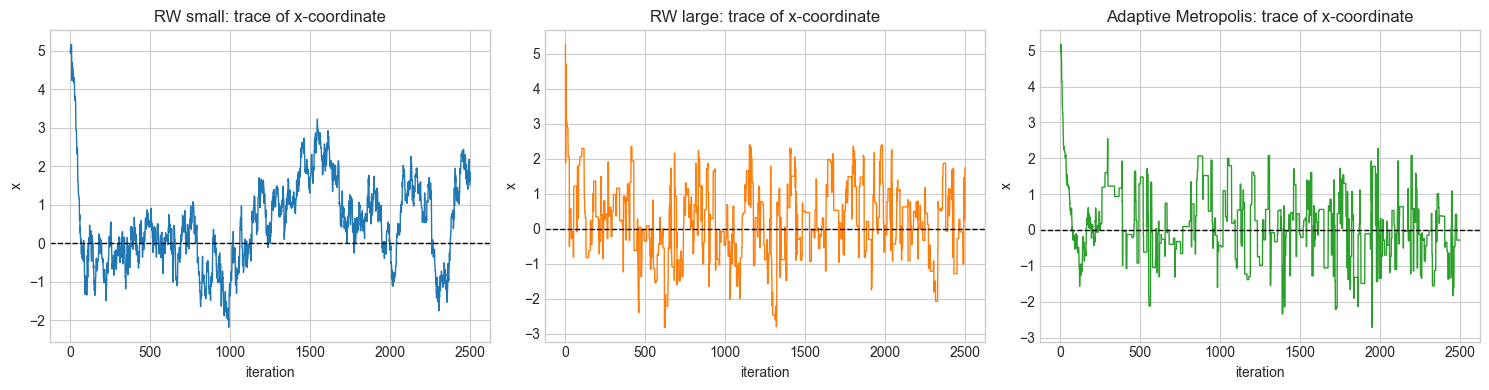

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, result), color in zip(
    axes,
    sampler_results_2d.items(),
    ["#1f77b4", "#ff7f0e", "#2ca02c"],
):
    ax.plot(result.samples[:2500, 0], color=color, lw=1.0)
    ax.axhline(0.0, color="black", ls="--", lw=1.0)
    ax.set_title(f"{name}: trace of x-coordinate")
    ax.set_xlabel("iteration")
    ax.set_ylabel("x")

plt.tight_layout()
plt.show()


### Conclusion of Experiment 2

The adaptive chain usually gives the best balance between movement and acceptance. It is not guaranteed to accept the most proposals, but it often yields a much larger effective sample size because it learns a proposal covariance that is closer to the geometry of the target.

This illustrates the main point of adaptive MCMC: the proposal distribution should fit the shape of the target, and adaptation offers a practical way to learn that shape during the run.


## 6. Conclusion

This notebook connects the basic Metropolis-Hastings chapter with the broader MCMC chapter through two experiments.

The main conclusions are:

1. **Metropolis-Hastings constructs a valid Markov chain by enforcing detailed balance with respect to the target density.**
2. **The proposal distribution has a major impact on practical performance.**
3. **For asymmetric heavy-tailed targets, a multiplicative proposal can be better than a simple additive random walk.**
4. **For correlated multivariate targets, Adaptive Metropolis can improve efficiency by learning the covariance structure online.**

So the project confirms a central lesson of MCMC: mathematical correctness is essential, but efficiency depends on choosing or learning a proposal that respects the geometry of the target distribution.
